In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sp
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)   # fixo a semente pra dar sempre o mesmo resultado
sns.set()   # ligo o estilo do seaborn pra todos os graficos

In [2]:
horas = np.random.normal(8, 2.5, 300)   # horas de estudo por semana de 300 alunos
notas = horas * 0.7 + np.random.normal(2, 1, 300)   # a nota acompanha as horas mais um ruido
notas = np.clip(notas, 0, 10)   # prendo entre 0 e 10 porque nota nao passa disso

print(horas[:5].round(2))   # olho os 5 primeiros so pra conferir o formato
print(notas[:5].round(2))

[ 9.24  7.65  9.62 11.81  7.41]
[ 7.64  6.8   9.48 10.    7.17]


In [3]:
print(np.mean(notas).round(2))   # onde a turma esta centrada
print(np.median(notas).round(2))   # o aluno do meio bem perto da media
print(np.var(notas).round(2))   # variancia esta ao quadrado
print(np.std(notas).round(2))   # desvio na mesma unidade da nota entao consigo ler

7.46
7.62
3.0
1.73


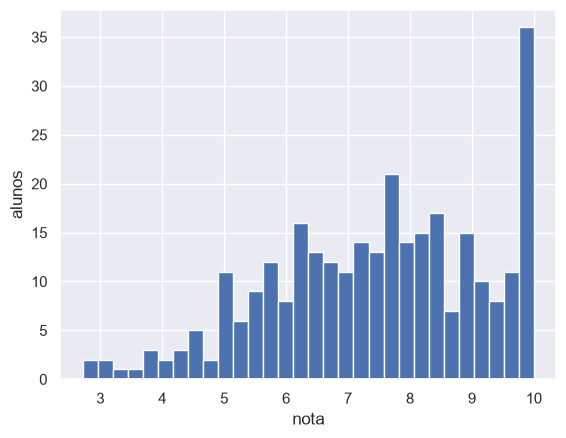

In [4]:
plt.hist(notas, 30)   # o formato de sino aparece porque gerei a partir de uma normal
plt.xlabel('nota')
plt.ylabel('alunos')
plt.show()

In [5]:
notas_com_erro = np.append(notas, [1000])   # simulo um lancamento errado de nota

print(np.mean(notas).round(2), '->', np.mean(notas_com_erro).round(2))   # a media foge
print(np.median(notas).round(2), '->', np.median(notas_com_erro).round(2))   # a mediana quase nao sente
# um unico valor absurdo ja estraga a media por isso prefiro a mediana quando desconfio dos dados

7.46 -> 10.76
7.62 -> 7.63


In [6]:
print(sp.skew(notas).round(3))   # perto de zero a curva e simetrica
print(sp.kurtosis(notas).round(3))   # perto de zero sem excesso de valor extremo

print(sp.skew(notas_com_erro).round(3))   # com o erro a cauda foi puxada pra direita
print(sp.kurtosis(notas_com_erro).round(3))   # e o peso da cauda disparou
# esses dois numeros medem exatamente o estrago que eu vi na celula anterior

-0.355
-0.541
17.239
295.456


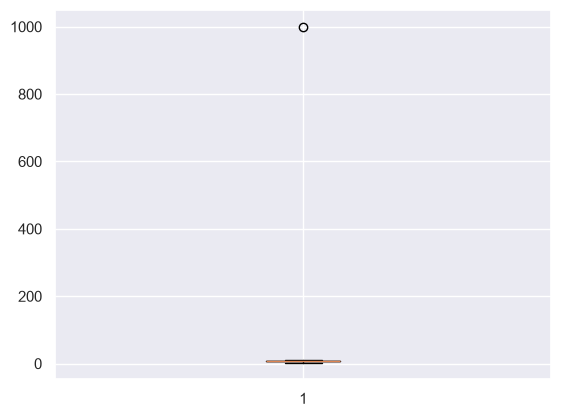

In [7]:
plt.boxplot(notas_com_erro)
plt.show()   # a nota errada aparece como ponto solto la em cima fora da caixa

In [8]:
print(np.percentile(notas, 50).round(2))   # percentil 50 e a mediana
print(np.percentile(notas, 20).round(2))   # abaixo desse ponto estao os 20 por cento piores
print(np.percentile(notas, 90).round(2))   # e acima desse os 10 por cento melhores

corte = np.percentile(notas, 90)
print((notas >= corte).sum(), 'alunos no topo dos 10 por cento')
# uso percentil e nao media porque ele nao se desloca com valor extremo

7.62
5.88
9.95
30 alunos no topo dos 10 por cento


In [9]:
def de_mean(x):
    return [xi - np.mean(x) for xi in x]   # o quanto cada ponto se afasta da media

def covariance(x, y):
    return np.dot(de_mean(x), de_mean(y)) / (len(x) - 1)   # multiplico os afastamentos das duas

def correlation(x, y):
    return covariance(x, y) / x.std() / y.std()   # divido pelo desvio de cada uma

print(covariance(horas, notas).round(3))   # o valor e alto mas depende da escala nao sei julgar sozinho
print(correlation(horas, notas).round(3))   # ja este fica entre -1 e 1, entao consigo ler o valor sozinho
print(np.corrcoef(horas, notas)[0, 1].round(3))   # bate com a funcao pronta minha conta esta certa

3.58
0.842
0.839


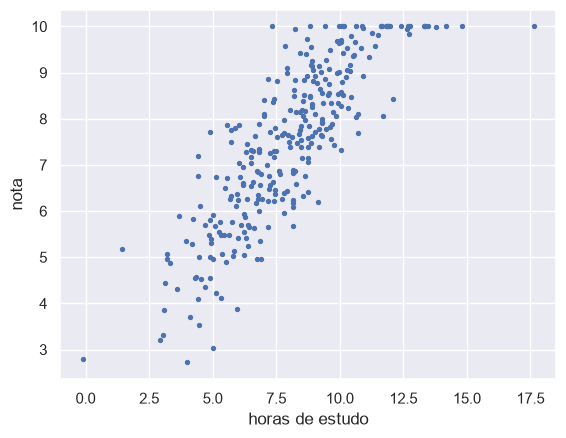

In [10]:
plt.scatter(horas, notas, s=8)   # a nuvem sobe da esquerda pra direita
plt.xlabel('horas de estudo')   # e a correlacao alta que calculei aparecendo no desenho
plt.ylabel('nota')
plt.show()

In [11]:
faltas = np.random.randint(0, 15, 300)   # gerei sem nenhuma ligacao com as horas
print(correlation(horas, faltas).round(3))
# deu perto de zero entao nao existe relacao linear aqui
# coloquei o caso com relacao e o sem relacao lado a lado pra comparar

0.122


In [12]:
turmas = np.random.choice(['A', 'B', 'C'], 300)   # distribuo os alunos em tres turmas

df = pd.DataFrame({'turma': turmas,
                   'horas': horas.round(1),
                   'nota': notas.round(1),
                   'faltas': faltas})   # junto tudo numa tabela pra usar o pandas daqui pra frente
df.head()

,turma,horas,nota,faltas
0,A,9.2,7.6,14
1,A,7.7,6.8,3
2,B,9.6,9.5,11
3,C,11.8,10.0,12
4,A,7.4,7.2,1


In [13]:
print(df.groupby('turma')['nota'].mean().round(2))   # nota media de cada turma
print(df['turma'].value_counts())   # quantos alunos em cada uma
print(sp.mode(df['faltas'], keepdims=True))   # a quantidade de falta que mais se repete

turma
A    7.34
B    7.60
C    7.47
Name: nota, dtype: float64
turma
A    109
B     96
C     95
Name: count, dtype: int64
ModeResult(mode=array([0], dtype=int32), count=array([24]))


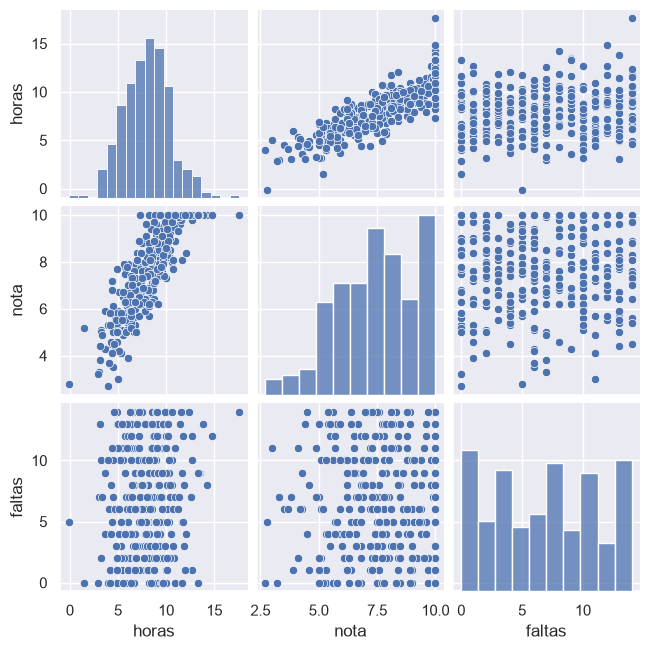

In [14]:
sns.pairplot(df[['horas', 'nota', 'faltas']], height=2.2)
plt.show()
# cruzo as tres colunas duas a duas de uma vez
# horas com nota forma uma faixa inclinada horas com faltas fica uma mancha sem direcao

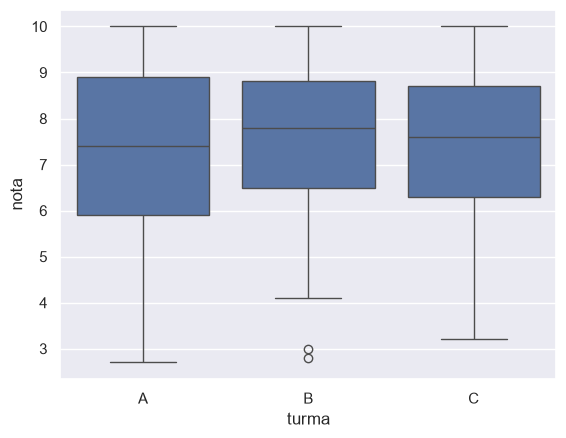

In [15]:
sns.boxplot(x='turma', y='nota', data=df)
plt.show()   # as tres caixas ficam parecidas porque sorteei a turma sem olhar a nota

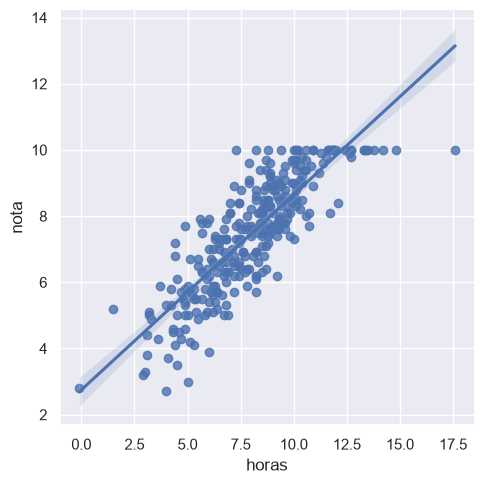

In [16]:
sns.lmplot(x='horas', y='nota', data=df)
plt.show()   # a reta de tendencia confirma no desenho a correlacao que calculei antes

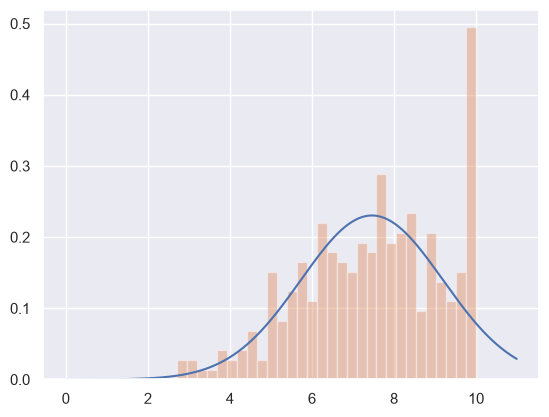

In [17]:
from scipy.stats import norm, expon, binom, poisson

x = np.arange(0, 11, 0.01)
plt.plot(x, norm.pdf(x, np.mean(notas), np.std(notas)))   # uso pdf porque nota e continua
plt.hist(notas, 30, density=True, alpha=0.4)   # density deixa o histograma na mesma escala da curva
plt.show()   # a curva teorica encaixa em cima dos dados

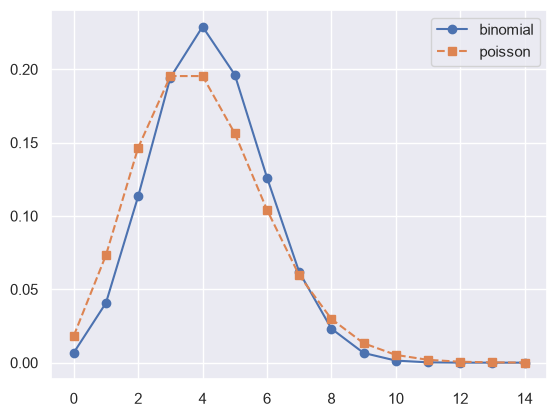

In [18]:
k = np.arange(0, 15)
plt.plot(k, binom.pmf(k, 14, 0.3), 'o-')   # aqui e pmf porque falta e contagem valor discreto
plt.plot(k, poisson.pmf(k, 4), 's--')   # as duas descrevem contagem mas por caminhos diferentes
plt.legend(['binomial', 'poisson'])
plt.show()

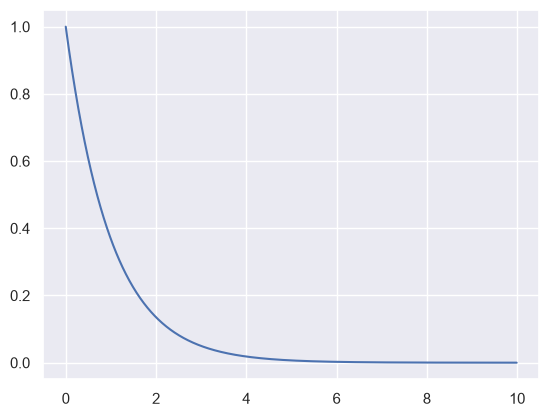

In [19]:
x = np.arange(0, 10, 0.01)
plt.plot(x, expon.pdf(x))
plt.show()   # exponencial serve pra tempo ate o proximo evento comeca alta e despenca

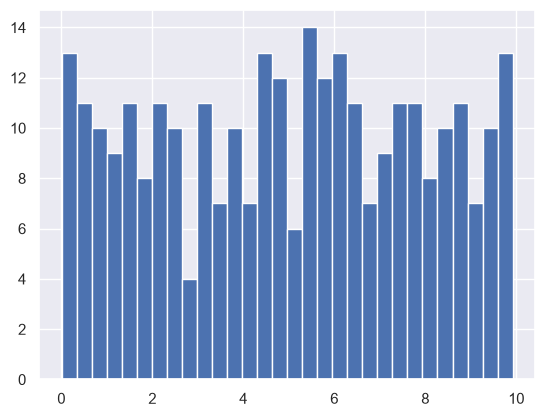

In [20]:
uniforme = np.random.uniform(0, 10, 300)

plt.hist(uniforme, 30)
plt.show()   # na uniforme as barras ficam na mesma altura nada a ver com o sino da nota

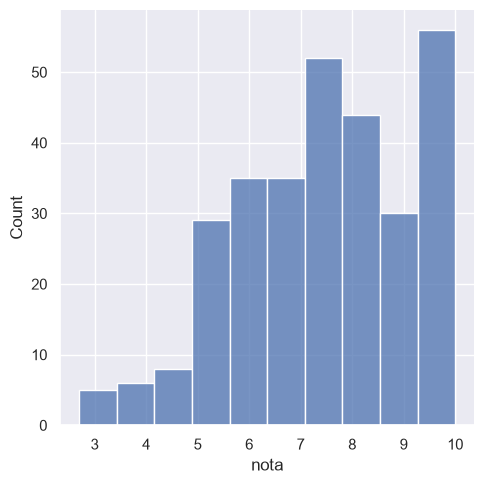

In [21]:
sns.displot(df['nota'])
plt.show()   # mesma distribuicao da nota agora desenhada pelo seaborn

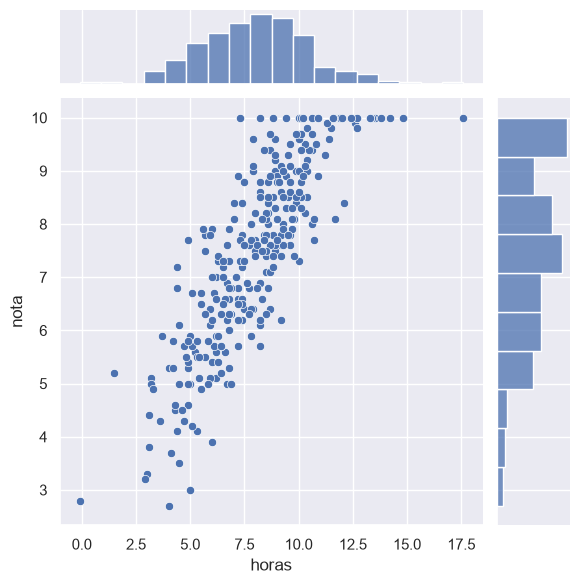

In [22]:
sns.jointplot(x='horas', y='nota', data=df)
plt.show()   # os pontos no meio e a distribuicao de cada eixo nas bordas

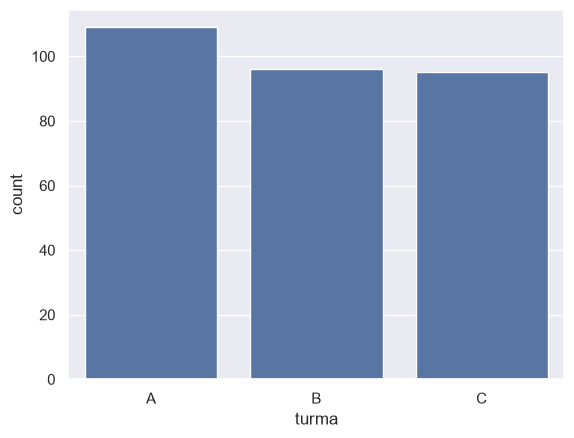

In [23]:
sns.countplot(x='turma', data=df)
plt.show()   # conta os alunos por turma direto do dataframe

faixa_horas  pouco  medio  muito
turma                           
A             5.22   7.21   9.00
B             5.43   7.62   8.97
C             5.67   7.27   9.26


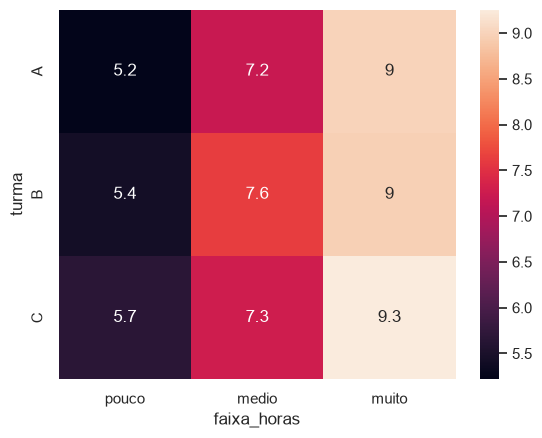

In [24]:
df['faixa_horas'] = pd.cut(df['horas'], bins=[0, 6, 9, 20], labels=['pouco', 'medio', 'muito'])
# o cut transforma a coluna continua em categoria pra poder cruzar numa tabela

tabela = df.pivot_table(index='turma', columns='faixa_horas', values='nota', aggfunc='mean', observed=True)
print(tabela.round(2))   # nota media no cruzamento de turma com faixa de estudo

sns.heatmap(tabela, annot=True)
plt.show()   # a cor muda no sentido das colunas e nao das linhas
# ou seja quem manda na nota e quanto o aluno estudou, nao a turma dele

In [25]:
df.to_csv('turma.csv', index=False)   # gravo a tabela o index=False evita salvar o indice como coluna
lido = pd.read_csv('turma.csv')   # leio de volta pra conferir que gravou certo
print(lido.shape)   # linhas e colunas
print(lido.describe().round(2))   # resumo estatistico de todas as colunas numericas

(300, 5)
        horas    nota  faltas
count  300.00  300.00  300.00
mean     7.98    7.46    6.76
std      2.46    1.74    4.35
min     -0.10    2.70    0.00
25%      6.30    6.28    3.00
50%      8.15    7.60    7.00
75%      9.60    8.83   10.00
max     17.60   10.00   14.00


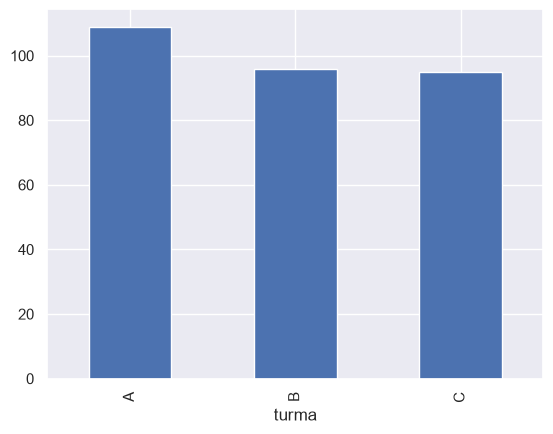

In [26]:
plt.figure()
df['turma'].value_counts().plot(kind='bar')
plt.savefig('grafico_turmas.png', format='png')   # gravo o grafico como imagem na pasta
plt.show()

In [27]:
aprovados = df[df['nota'] >= 6]   # considero aprovado quem tirou 6 ou mais

p_aprovado = len(aprovados) / len(df)   # chance de aprovacao olhando a turma toda
p_muito = len(df[df['horas'] >= 10]) / len(df)   # chance de ser um aluno que estuda muito
p_aprovado_dado_muito = len(df[(df['horas'] >= 10) & (df['nota'] >= 6)]) / len(df[df['horas'] >= 10])

print(round(p_aprovado, 3))
print(round(p_aprovado_dado_muito, 3))
# a segunda e bem maior, entao saber que o aluno estudou muito muda a chance dele passar

0.787
1.0


In [28]:
print(round(p_aprovado * p_muito, 4))   # se fossem independentes
print(round(len(df[(df['horas'] >= 10) & (df['nota'] >= 6)]) / len(df), 4))   # o que acontece de verdade
# os dois numeros deram diferentes confirmando que as variaveis se relacionam
# se fossem independentes eles bateriam

0.16
0.2033


In [29]:
p_muito_dado_aprovado = p_aprovado_dado_muito * p_muito / p_aprovado   # teorema de bayes
print(round(p_muito_dado_aprovado, 3))
print(round(len(df[(df['horas'] >= 10) & (df['nota'] >= 6)]) / len(aprovados), 3))
# bayes inverte a pergunta, antes eu sabia a nota dado o estudo e agora sei o estudo dado a nota
# o valor bate com a contagem direta entao a formula fecha

0.258
0.258


In [30]:
resumo = df.groupby('turma').agg({'nota': ['mean', 'median'], 'horas': 'mean'}).round(2)
print(resumo)   # fecho juntando as medidas do comeco numa tabela so
print('turma com maior nota media:', df.groupby('turma')['nota'].mean().idxmax())

       nota        horas
       mean median  mean
turma                   
A      7.34    7.4  7.86
B      7.60    7.8  8.03
C      7.47    7.6  8.07
turma com maior nota media: B
